# Fear and Greed indicators

AIM: Find indicators to estimate the current market sentiment, and for each one curate a [Perplexity Page](https://www.perplexity.ai/hub/blog/perplexity-pages) commenting the rationale and critics about it.

In [1]:
import os
import dotenv # pip install python-dotenv
import pandas as pd

import yfinance as yf # pip install yfinance
from fredapi import Fred # pip install fredapi

dotenv.load_dotenv()

print("yfinance version:", yf.__version__)

yfinance version: 0.2.65


## F&G Indicator #1: margin borrowing

https://www.perplexity.ai/page/margin-debt-as-percentage-of-m-9lQvy1AIRXC1pvm0J45Z3A

In [2]:
sp500tr_raw = yf.Ticker('^SP500TR').history(period='max', auto_adjust=True)
display(sp500tr_raw)
sp500tr_ss = sp500tr_raw["Close"]
sp500tr_ss.index = sp500tr_ss.index.date

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1988-01-04 00:00:00-05:00,256.019989,256.019989,256.019989,256.019989,0,0.0,0.0
1988-01-05 00:00:00-05:00,258.769989,258.769989,258.769989,258.769989,0,0.0,0.0
1988-01-06 00:00:00-05:00,259.029999,259.029999,259.029999,259.029999,0,0.0,0.0
1988-01-07 00:00:00-05:00,261.209991,261.209991,261.209991,261.209991,0,0.0,0.0
1988-01-08 00:00:00-05:00,243.550003,243.550003,243.550003,243.550003,0,0.0,0.0
...,...,...,...,...,...,...,...
2025-10-20 00:00:00-04:00,14838.320312,14958.740234,14838.320312,14938.290039,0,0.0,0.0
2025-10-21 00:00:00-04:00,14941.929688,14975.950195,14910.530273,14938.830078,0,0.0,0.0
2025-10-22 00:00:00-04:00,14952.349609,14953.259766,14762.370117,14859.330078,0,0.0,0.0


In [3]:
fred = Fred(api_key=os.getenv("FRED_API_KEY"))
m2_raw = fred.get_series('M2SL')
display(m2_raw)
m2_ss = pd.Series(m2_raw)
m2_ss.index = pd.to_datetime(m2_ss.index)

1959-01-01      286.6
1959-02-01      287.7
1959-03-01      289.2
1959-04-01      290.1
1959-05-01      292.2
               ...   
2025-04-01    21805.1
2025-05-01    21884.6
2025-06-01    22022.1
2025-07-01    22115.8
2025-08-01    22195.4
Length: 800, dtype: float64

In [4]:
margin_raw = pd.read_excel('https://www.finra.org/sites/default/files/2021-03/margin-statistics.xlsx')
display(margin_raw)
margin_ss = margin_raw.set_index('Year-Month')["Debit Balances in Customers' Securities Margin Accounts"]
margin_ss.index = pd.to_datetime(margin_ss.index)

,Year-Month,Debit Balances in Customers' Securities Margin Accounts,Free Credit Balances in Customers' Cash Accounts,Free Credit Balances in Customers' Securities Margin Accounts
0,2025-09,1126494,204106,194884.0
1,2025-08,1059723,188221,181563.0
2,2025-07,1022548,194712,186672.0
3,2025-06,1007961,200573,185584.0
4,2025-05,920960,187685,176698.0
...,...,...,...,...
340,1997-05,111097,66879,NaN
341,1997-04,102842,64825,NaN
342,1997-03,104835,69553,NaN
343,1997-02,103886,67058,NaN


In [5]:
df = (
    sp500tr_ss
    .div(sp500tr_ss.iloc[-1]/10) # rescale to be 10 as last value 
    .rename("S&P 500 Total Returns")
    .to_frame()
    .join(margin_ss.div(1e6).rename("Margin (T$)")) # raw is in M$
    .join(m2_ss.div(1e3).rename("M2 (T$)")) # raw is in B$
    .ffill()
    .assign(**{
        "%Margin/M2": lambda x: x["Margin (T$)"] / x["M2 (T$)"] * 100
    })
)
df

,S&P 500 Total Returns,Margin (T$),M2 (T$),%Margin/M2
1988-01-04,0.169945,NaN,NaN,NaN
1988-01-05,0.171770,NaN,NaN,NaN
1988-01-06,0.171943,NaN,NaN,NaN
1988-01-07,0.173390,NaN,NaN,NaN
1988-01-08,0.161667,NaN,NaN,NaN
...,...,...,...,...
2025-10-20,9.915950,1.059723,22.1954,4.774516
2025-10-21,9.916309,1.059723,22.1954,4.774516
2025-10-22,9.863537,1.059723,22.1954,4.774516
2025-10-23,9.921154,1.059723,22.1954,4.774516


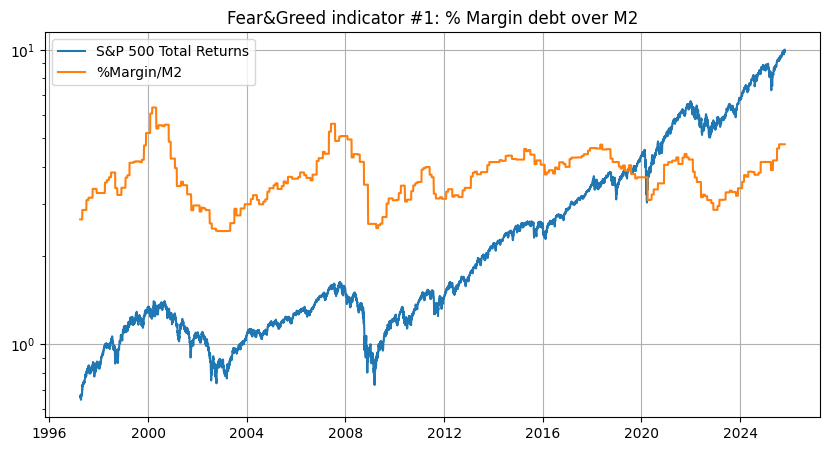

In [6]:
TITLE = "Fear&Greed indicator #1: % Margin debt over M2"
INCLUDE = ["S&P 500 Total Returns", "%Margin/M2"]
# plotly
import plotly.express as px # pip install plotly
fig = px.line(
    df.dropna()[INCLUDE].reset_index().melt(id_vars="index"),
    x="index",
    y="value",
    color="variable",
    title=TITLE,
).update_layout(
    yaxis_type="log",
    width=800,
).show()
# matplotlib
import matplotlib.pyplot as plt
df_plot = df.dropna()[INCLUDE]
fig, ax = plt.subplots(figsize=(10, 5))
for col in df_plot.columns:
    ax.plot(df_plot.index, df_plot[col], label=col)
ax.set_yscale('log')
ax.set_title(TITLE)
ax.legend()
ax.grid()
plt.show()